In [1]:
import pandas as pd

df = pd.read_json("Sarcasm_Headlines_Dataset_v2.json", lines=True)
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [2]:
df = df[['headline', 'is_sarcastic']].dropna().drop_duplicates()
df.columns = ['text', 'label']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=50)
X_test = pad_sequences(X_test, maxlen=50)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

model = Sequential([
    Input(shape=(50,)),
    Embedding(5000, 32),
    SimpleRNN(32),
    Dense(1, activation="sigmoid")
])

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7706 - loss: 0.4648 - val_accuracy: 0.8314 - val_loss: 0.3872
Epoch 2/5
571/571 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8957 - loss: 0.2582 - val_accuracy: 0.8399 - val_loss: 0.3621
Epoch 3/5
571/571 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9483 - loss: 0.1424 - val_accuracy: 0.8242 - val_loss: 0.4692
Epoch 4/5
571/571 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9737 - loss: 0.0825 - val_accuracy: 0.8200 - val_loss: 0.5512
Epoch 5/5
571/571 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9927 - loss: 0.0263 - val_accuracy: 0.8103 - val_loss: 0.6790


In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 82.34%


The Simple RNN achieved 82.34% test accuracy. The increasing training accuracy and decreasing validation accuracy after the second epoch indicate that the model started overfitting the training data.

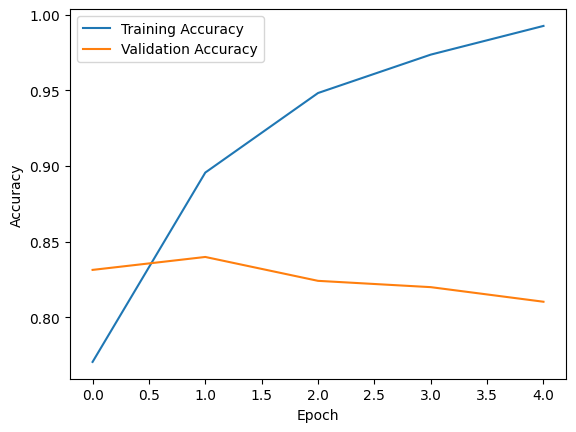

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Vanishing gradient**

A plain RNN can struggle with long sequences because gradients can become extremely small during backpropagation. This makes it difficult for the model to learn and remember information from words appearing much earlier in the sequence.